<a href="https://colab.research.google.com/github/aysenuruyar-rgb/DSA210-Proj/blob/main/notebook/05_ML_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Modeling

This notebook applies machine learning methods to predict Istanbul dam occupancy levels using weather variables, lag features, rolling averages, and seasonal features.

The goal is to evaluate whether engineered temporal features improve prediction performance compared to short-term weather variables alone.

In [1]:
import pandas as pd

df = pd.read_csv("featured_dataset.csv", index_col=0)

## Feature Selection and Train-Test Split

The dataset includes weather variables, lagged occupancy variables, rolling averages, and seasonal encoding features.

Since the data is time-series based, a chronological train-test split is used instead of random splitting to preserve temporal order.

In [2]:
df.index = pd.to_datetime(df.index)

y = df["GENERAL_DAM_OCCUPANCY_RATE"]

X = df[[
    "dam_lag_1",
    "dam_lag_3",
    "rain_lag_1",
    "rain_lag_3",
    "snow_lag_1",
    "temp_lag_1",
    "rain_3m_avg",
    "temp_3m_avg",
    "rain_snow_total",
    "month_sin",
    "month_cos",
    "is_rainy"
]]


split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R^2:", r2)


MAE: 2.9973319169801256
R^2: 0.9547374699412862


## Linear Regression Results

Linear Regression achieved improved performance after the inclusion of lagged occupancy and seasonal features.

The results suggest that historical reservoir levels are much more informative than short-term weather variables alone.

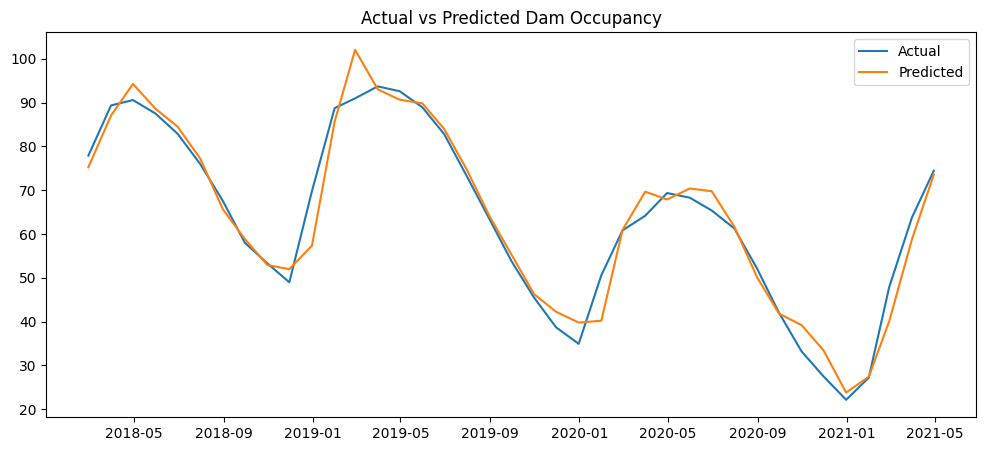

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Dam Occupancy")
plt.show()

The predicted values generally follow the overall trend of actual reservoir occupancy levels, although some deviations remain during periods of rapid fluctuation.

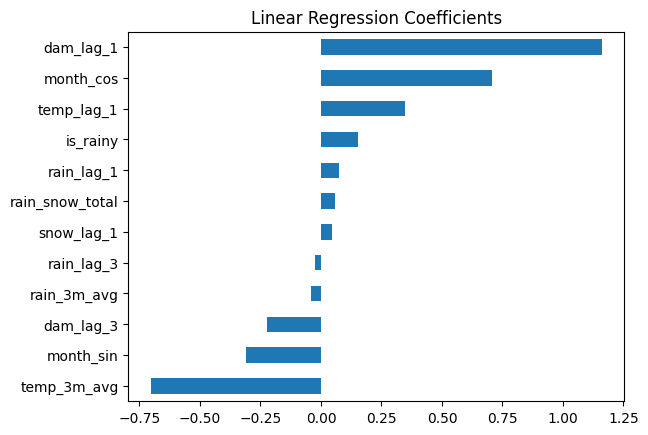

In [ ]:
import pandas as pd

importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Linear Regression Coefficients")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("RF MSE:", mean_squared_error(y_test, y_pred_rf))
print("RF R²:", r2_score(y_test, y_pred_rf))

RF MSE: 25.182359366683183
RF R²: 0.9373764046840373


## Random Forest Results

Random Forest Regression was able to capture more complex and non-linear relationships between the variables.

The model produced strong predictive performance, indicating that reservoir systems depend on multiple interacting environmental and temporal factors.

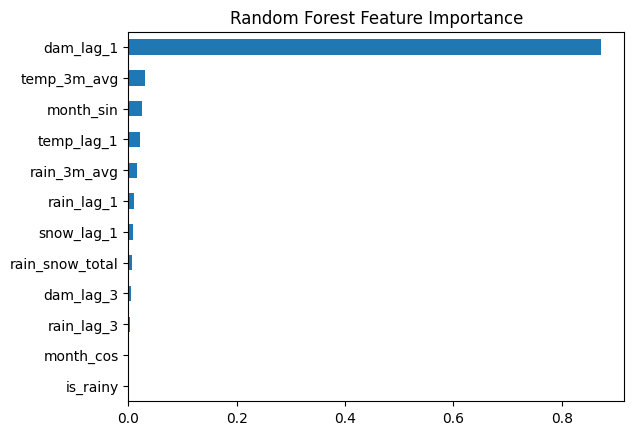

In [ ]:
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)

rf_importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

The feature importance analysis shows that lagged dam occupancy variables are among the strongest predictors of future reservoir levels.

This finding supports the idea that reservoir systems are heavily influenced by accumulated and delayed environmental effects rather than only daily weather conditions.

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [r2, r2_score(y_test, y_pred_rf)],
    "MAE": [mae, mean_absolute_error(y_test, y_pred_rf)]
})

results

,Model,R2,MAE
0,Linear Regression,0.954737,2.997332
1,Random Forest,0.937376,3.924415


# Final Conclusions

- Weather variables alone have limited explanatory power.
- Lagged and rolling occupancy features significantly improve prediction performance.
- Seasonal and historical patterns play a major role in reservoir behavior.
- Reservoir systems are influenced by long-term cumulative processes rather than only short-term rainfall events.

Overall, the machine learning results support the earlier hypothesis testing findings regarding the complexity of water storage systems.